<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/notebooks/MissingDataStrategyEvaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


# Exploratory Data Analysis — Content Refresh / Traffic Decay Dataset

Goal of this notebook: understand the shape of the data, decide how to handle missing values, and check whether that decision meaningfully changes what a baseline model learns — before moving on to the real feature-engineering notebook.

## 1. Setup & Imports

Everything the notebook needs, in one place.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 — required before importing IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 2. Load Data

In [3]:
DATA_PATH = "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)

# Binary target: is this page's traffic trending down?
df["is_declining"] = (df["trend_direction"].str.lower() == "down").astype(int)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 30000 rows x 45 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7,1


## 3. First Look: Structure & Missingness

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
provider_used,21438,71.5
word_count_tier,7699,25.7
char_count,7699,25.7
word_count,7699,25.7
char_count_tier,7699,25.7
model_used,5733,19.1
trend_pct,3388,11.3
competition_level,2610,8.7
search_volume,2468,8.2
competition,2468,8.2


## 4. Reusable EDA Plotting Functions

Defined once, used everywhere below, so every dataset variant (raw / dropped / imputed) gets plotted the exact same way and is actually comparable.

In [6]:
def plot_distributions(data, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(data["impressions_90d"], bins=50, log_scale=True, color="blue", ax=axes[0])
    axes[0].set_title(f"Distribution of 90-Day Impressions (Log Scale){title_suffix}")
    axes[0].set_xlabel("Log Impressions")

    sns.histplot(data["avg_position"], bins=50, color="orange", ax=axes[1])
    axes[1].set_title(f"Distribution of Average Position{title_suffix}")
    axes[1].set_xlabel("Average Position")

    plt.tight_layout()
    plt.show()


def plot_danger_zone(data, title_suffix=""):
    data = data.copy()  # never mutate the caller's dataframe
    data["pos_bin"] = pd.qcut(data["avg_position"], q=4, duplicates="drop")
    decay_rates = data.groupby("pos_bin")["is_declining"].mean() * 100

    plt.figure(figsize=(8, 4))
    decay_rates.plot(kind="bar", color="crimson")
    plt.title(f"Traffic Decay Rate by Ranking Position Quartile{title_suffix}")
    plt.ylabel("% of Pages Declining")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_correlation(data, title_suffix=""):
    core_features = ["impressions_90d", "avg_position", "days_since_last_update",
                      "content_age_days", "is_declining"]
    corr = data[core_features].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix of Core Search Metrics{title_suffix}")
    plt.tight_layout()
    plt.show()

## 5. Baseline EDA (Raw Data)

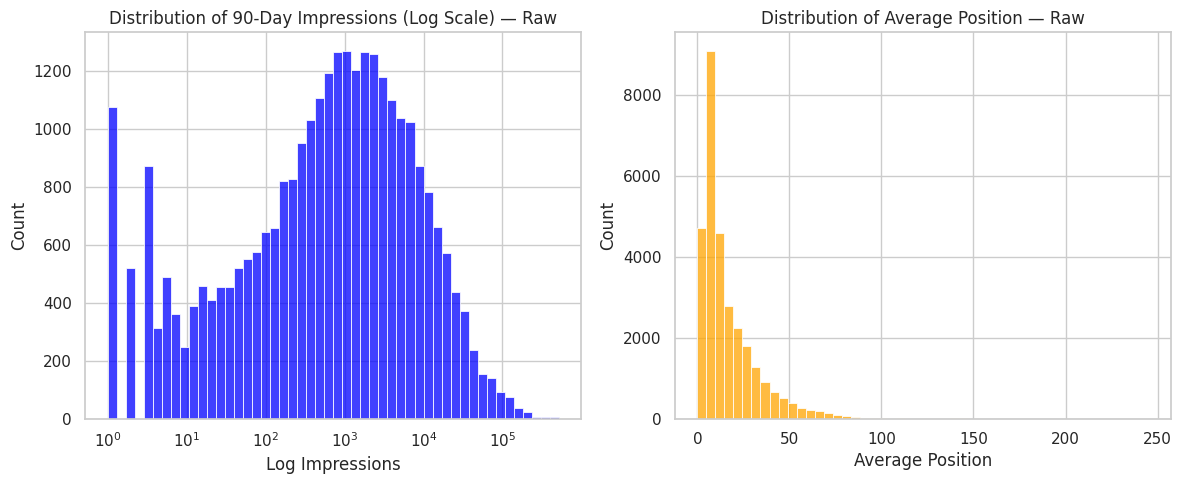

In [7]:
plot_distributions(df, " — Raw")

/tmp/ipykernel_2872/4101621072.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decay_rates = data.groupby("pos_bin")["is_declining"].mean() * 100


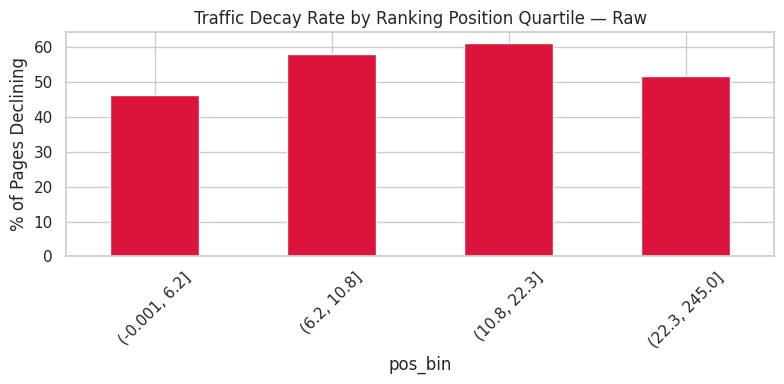

In [8]:
plot_danger_zone(df, " — Raw")

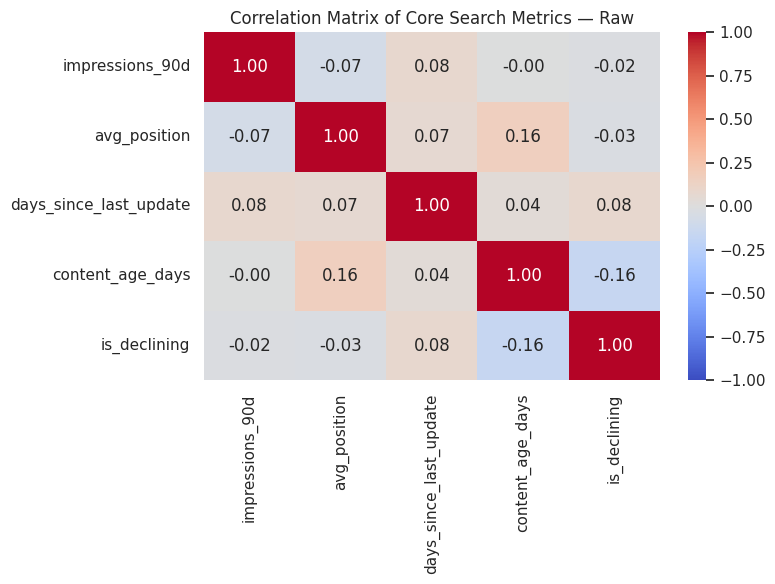

In [9]:
plot_correlation(df, " — Raw")

## 6. Missing Data: Comparing Handling Strategies

`word_count` and `search_volume` are the columns carrying most of the missing values (see the table in section 3). We compare four ways of handling that: dropping rows, median imputation, iterative (MICE) imputation, and KNN imputation — then look at how each choice changes the distributions and correlations before picking one for modeling.

### 6.1 Prepare Feature / Target Matrices

In [10]:
drop_cols = ["content_id", "client_id", "trend_direction", "trend_pct", "is_declining"]
X = df.drop(columns=drop_cols)
y = df["is_declining"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numerical features (29): ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']
Categorical features (11): ['competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier']


### 6.2 Strategy A — Drop Rows with Missing Values

In [11]:
df_clean = df.dropna().copy()
print(f"Shape after dropping NaNs: {df_clean.shape} (lost {len(df) - len(df_clean)} rows)")

Shape after dropping NaNs: (7350, 45) (lost 22650 rows)


### 6.3 Strategy B — Median Imputation

In [12]:
df_imputed = df.copy()
numeric_cols = ["impressions_90d", "avg_position", "days_since_last_update", "content_age_days"]

median_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_cols] = median_imputer.fit_transform(df_imputed[numeric_cols])

print(f"Imputed dataset shape: {df_imputed.shape}")

Imputed dataset shape: (30000, 45)


> **Worth checking yourself:** `numeric_cols` here is the same four columns used for the EDA plots — but the missingness table in section 3 shows the actual gaps are in `word_count` and `search_volume`, which aren't in this list. Is that intentional (these four really are clean and this imputation does nothing), or a leftover from an earlier version of the analysis? Worth tracing through before you rely on this for modeling.

### 6.4 Strategy C — Iterative (MICE) Imputation

In [13]:
df_iter_imputed = df.copy()
iter_imputer = IterativeImputer(max_iter=10, random_state=42)
df_iter_imputed[numeric_cols] = iter_imputer.fit_transform(df_iter_imputed[numeric_cols])

print(f"Iteratively imputed dataset shape: {df_iter_imputed.shape}")

Iteratively imputed dataset shape: (30000, 45)


### 6.5 Comparing Clean vs. Median vs. Iterative

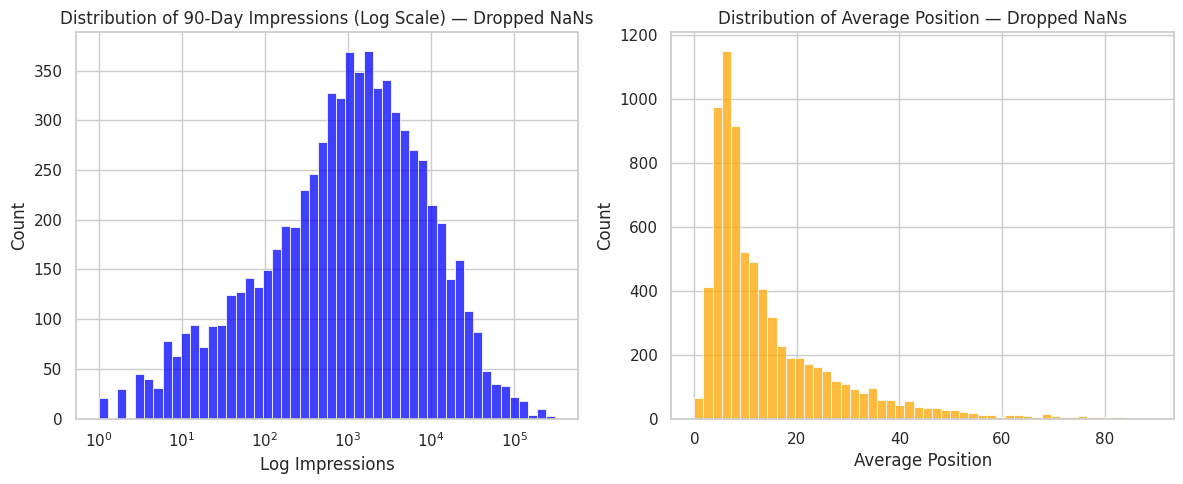

In [14]:
plot_distributions(df_clean, " — Dropped NaNs")

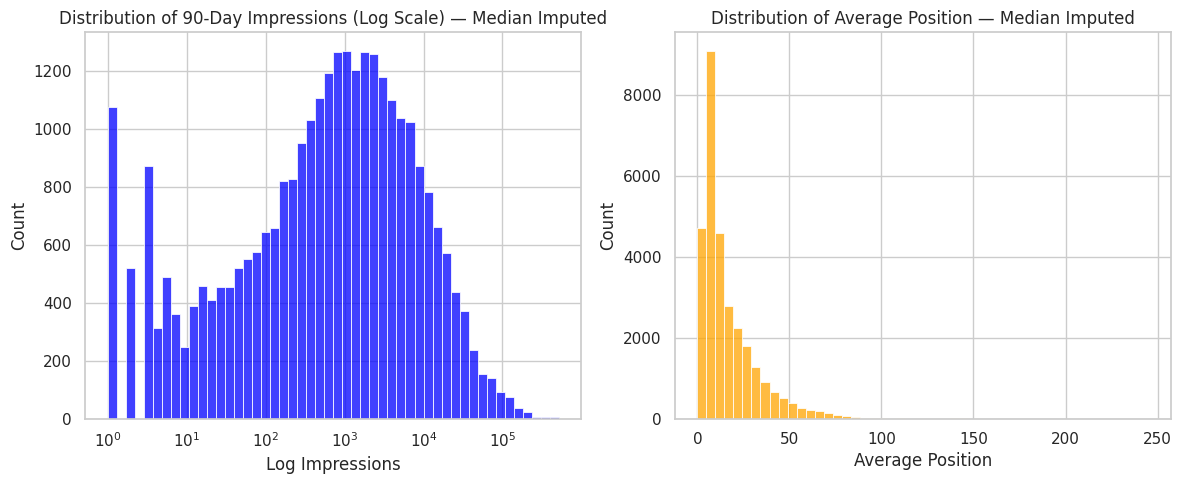

In [15]:
plot_distributions(df_imputed, " — Median Imputed")

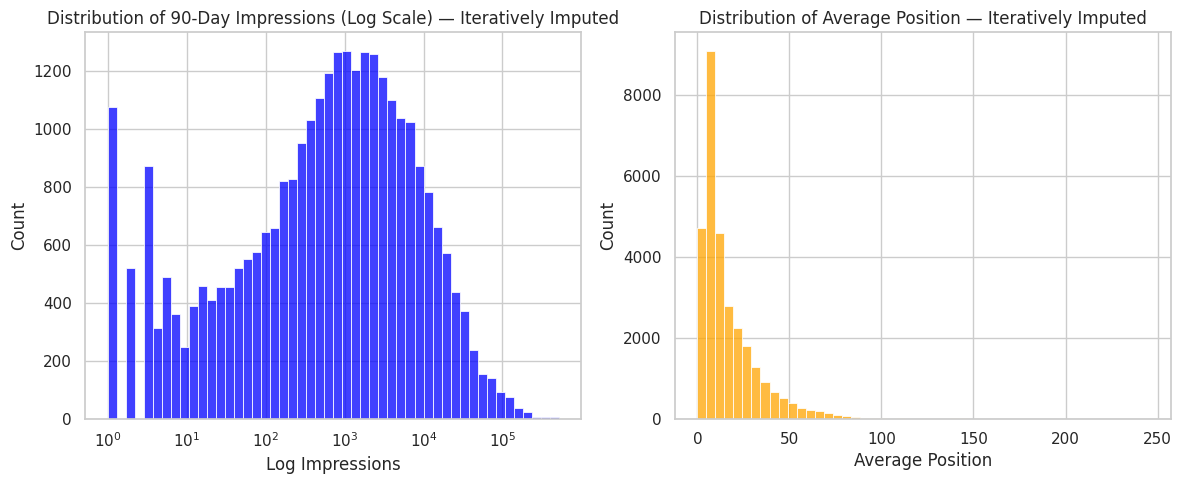

In [16]:
plot_distributions(df_iter_imputed, " — Iteratively Imputed")

/tmp/ipykernel_2872/4101621072.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decay_rates = data.groupby("pos_bin")["is_declining"].mean() * 100


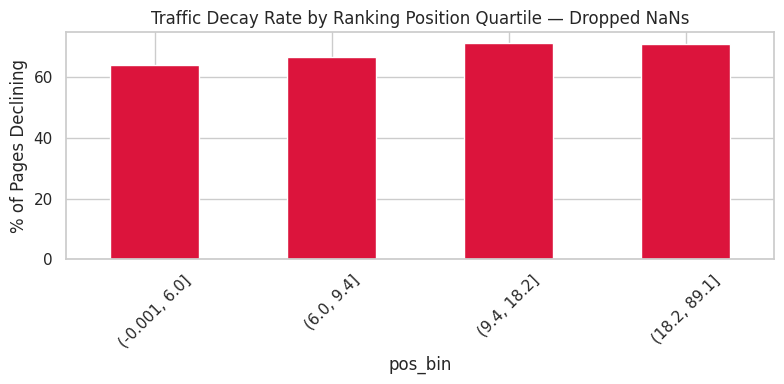

In [17]:
plot_danger_zone(df_clean, " — Dropped NaNs")

/tmp/ipykernel_2872/4101621072.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decay_rates = data.groupby("pos_bin")["is_declining"].mean() * 100


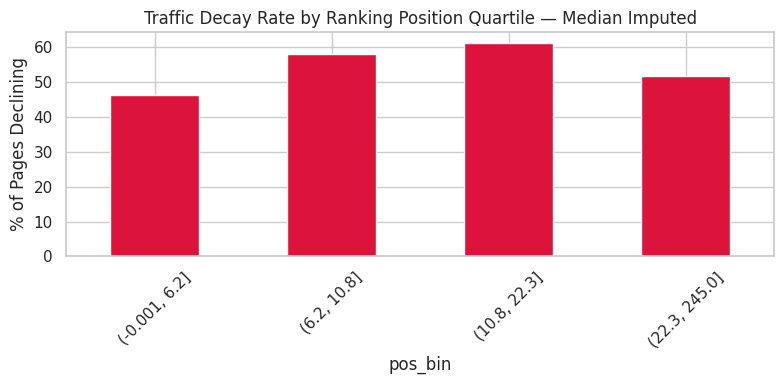

In [18]:
plot_danger_zone(df_imputed, " — Median Imputed")

/tmp/ipykernel_2872/4101621072.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decay_rates = data.groupby("pos_bin")["is_declining"].mean() * 100


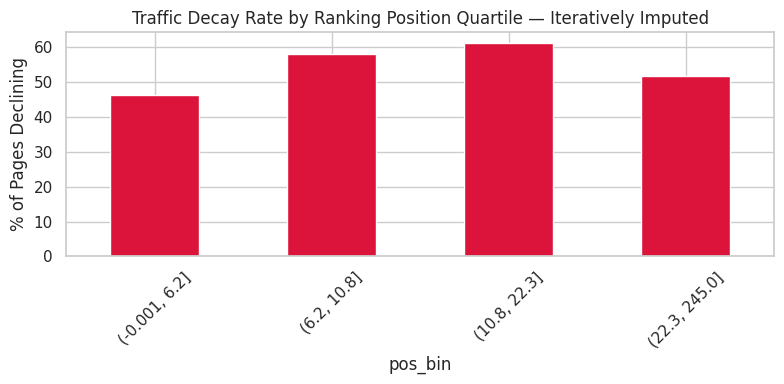

In [19]:
plot_danger_zone(df_iter_imputed, " — Iteratively Imputed")

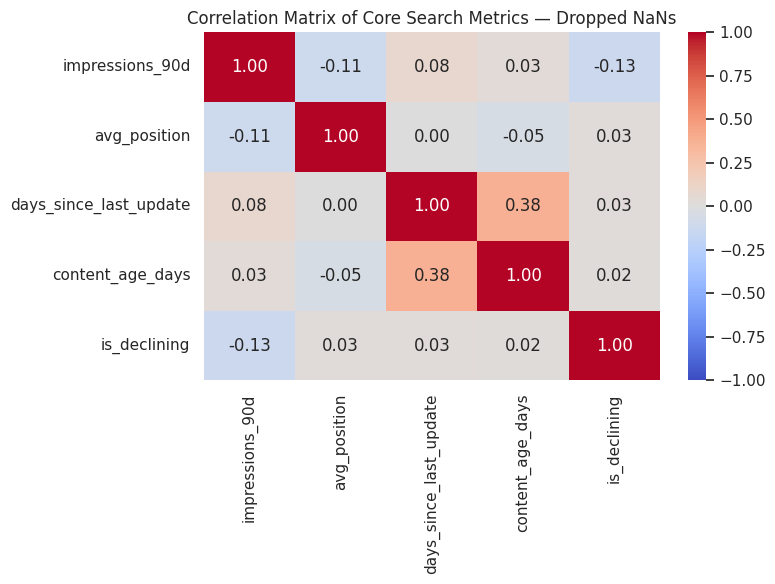

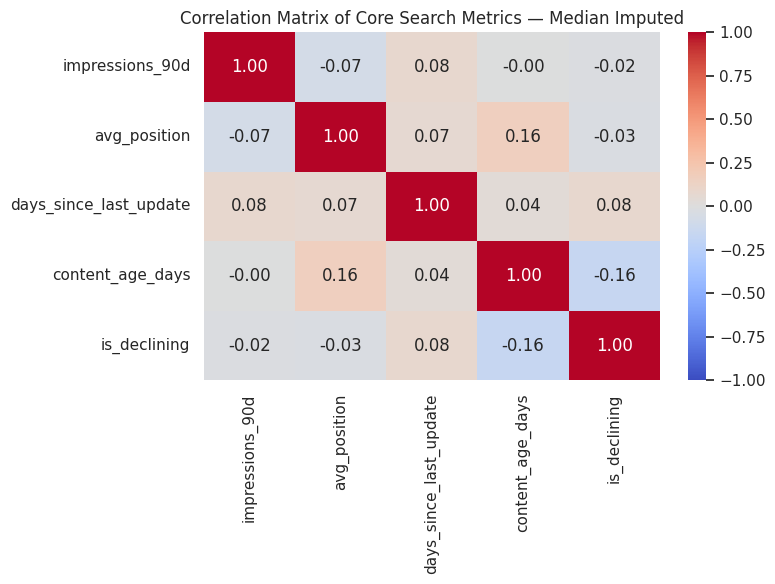

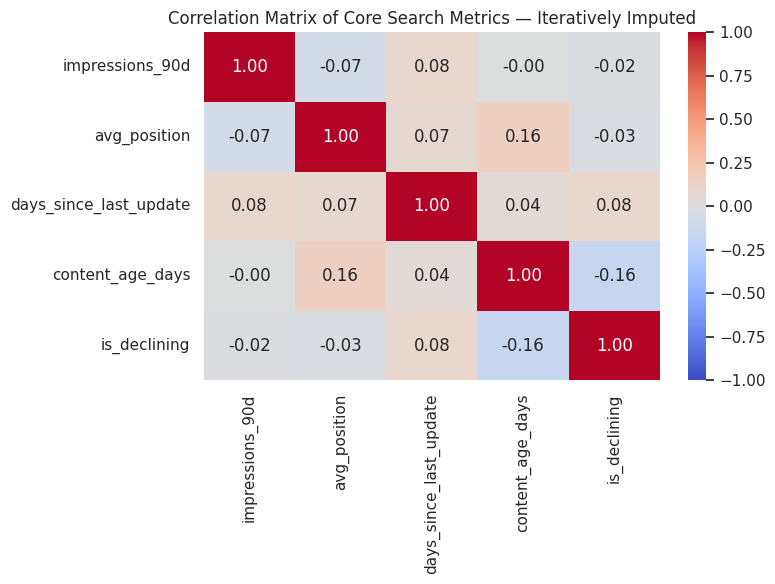

In [20]:
plot_correlation(df_clean, " — Dropped NaNs")
plot_correlation(df_imputed, " — Median Imputed")
plot_correlation(df_iter_imputed, " — Iteratively Imputed")

### 6.6 Strategy D — KNN Imputation

This comparison uses the columns that actually contain missing values (`word_count`, `search_volume`) alongside two always-populated features, so the differences between methods are visible.

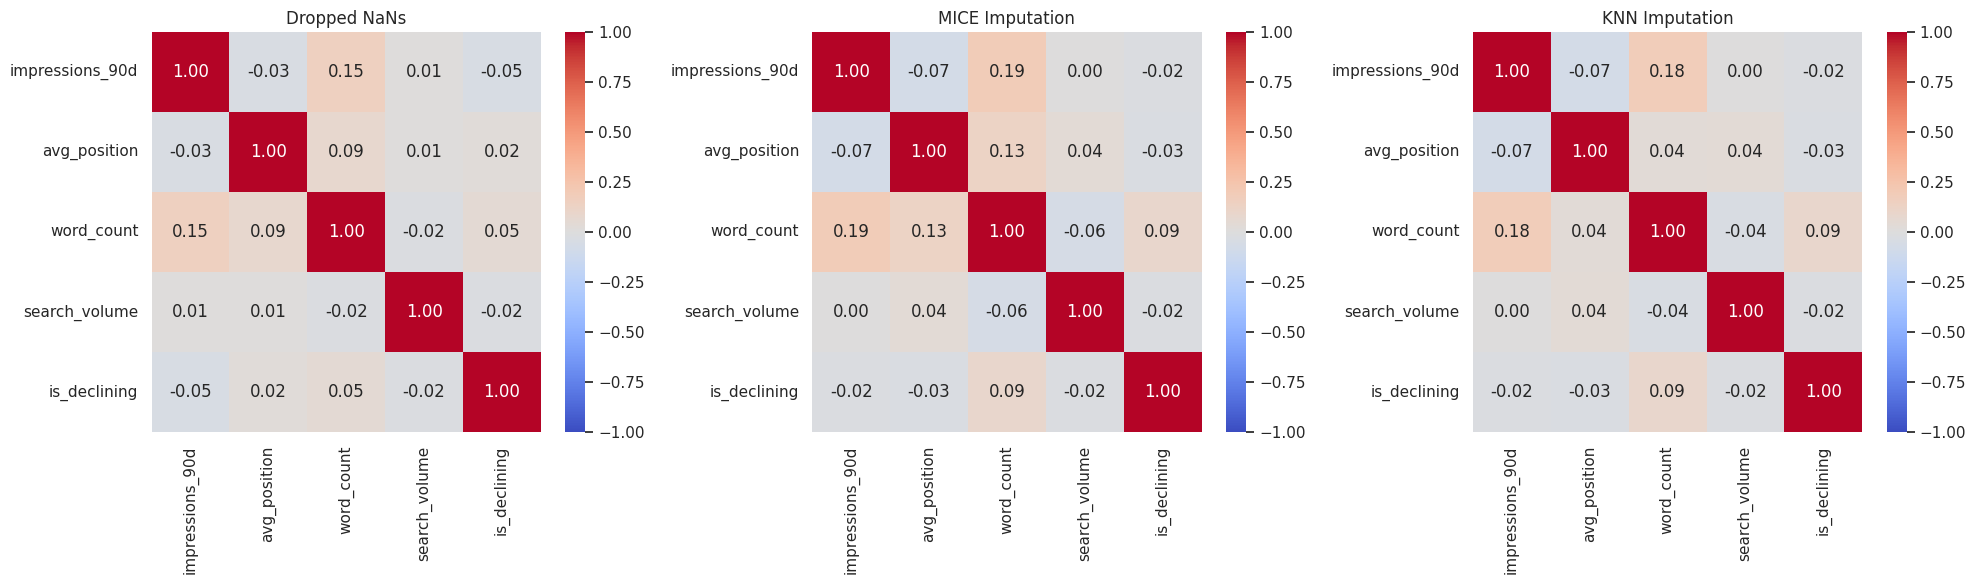

In [21]:
eval_cols = ["impressions_90d", "avg_position", "word_count", "search_volume", "is_declining"]

df_eval_clean = df[eval_cols].dropna()
corr_clean = df_eval_clean.corr()

mice_imputer_eval = IterativeImputer(max_iter=10, random_state=42)
df_eval_mice = pd.DataFrame(mice_imputer_eval.fit_transform(df[eval_cols]), columns=eval_cols)
corr_mice = df_eval_mice.corr()

knn_imputer = KNNImputer(n_neighbors=5)
df_eval_knn = pd.DataFrame(knn_imputer.fit_transform(df[eval_cols]), columns=eval_cols)
corr_knn = df_eval_knn.corr()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, corr, title in zip(axes, [corr_clean, corr_mice, corr_knn],
                           ["Dropped NaNs", "MICE Imputation", "KNN Imputation"]):
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax, vmin=-1, vmax=1)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Does Missingness Itself Carry a Signal?

Sometimes the fact that a value is *missing* is itself predictive — e.g. clients who never fill in `word_count` might behave differently from those who do. Check the correlation between "is missing" flags and the target directly.

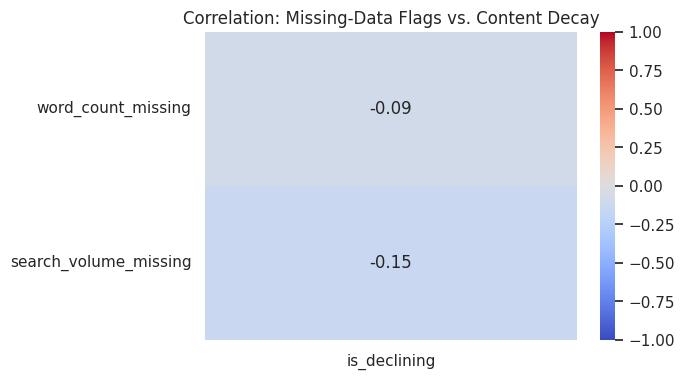

In [22]:
df_flags = df.copy()
df_flags["word_count_missing"] = df_flags["word_count"].isnull().astype(int)
df_flags["search_volume_missing"] = df_flags["search_volume"].isnull().astype(int)

flag_cols = ["word_count_missing", "search_volume_missing", "is_declining"]
flag_correlations = df_flags[flag_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(flag_correlations[["is_declining"]].drop("is_declining"), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: Missing-Data Flags vs. Content Decay")
plt.show()

## 8. Does the Imputation Strategy Change Downstream Model Performance?

Train the same baseline `RandomForestClassifier` under three regimes and compare the classification reports: drop NaNs, median-impute, and iterative-impute with missingness indicators.

### 8.1 Baseline — Drop NaNs

In [23]:
X_clean = df_clean.drop(columns=drop_cols)
y_clean = df_clean["is_declining"]
X_clean_encoded = pd.get_dummies(X_clean, columns=cat_cols, drop_first=True)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean_encoded, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_c, y_train_c)
y_pred_c = rf_baseline.predict(X_test_c)

print("Baseline (dropped NaNs) — Classification Report:")
print(classification_report(y_test_c, y_pred_c))

Baseline (dropped NaNs) — Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       469
           1       0.85      0.96      0.90      1001

    accuracy                           0.86      1470
   macro avg       0.86      0.80      0.82      1470
weighted avg       0.86      0.86      0.85      1470



### 8.2 Median-Imputation Pipeline

Same train/test split (by row) is reused for both pipeline variants below, so the comparison in 8.3 isn't confounded by a different split.

In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing_category")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_median = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

median_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_median),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])
median_pipeline.fit(X_train, y_train)
y_pred_median = median_pipeline.predict(X_test)

print("Median Imputation Pipeline — Classification Report:")
print(classification_report(y_test, y_pred_median))

Median Imputation Pipeline — Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      2748
           1       0.83      0.89      0.86      3252

    accuracy                           0.85      6000
   macro avg       0.85      0.84      0.84      6000
weighted avg       0.85      0.85      0.84      6000



### 8.3 Iterative Imputation + Missingness Indicators Pipeline

In [25]:
numeric_transformer_iter = Pipeline(steps=[
    ("imputer", IterativeImputer(max_iter=10, random_state=42, add_indicator=True)),
    ("scaler", StandardScaler())
])
categorical_transformer_iter = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing_category", add_indicator=True)),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_iter = ColumnTransformer(transformers=[
    ("num", numeric_transformer_iter, num_cols),
    ("cat", categorical_transformer_iter, cat_cols)
])

iter_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_iter),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
iter_pipeline.fit(X_train, y_train)
y_pred_iter = iter_pipeline.predict(X_test)

print("Iterative Imputation Pipeline — Classification Report:")
print(classification_report(y_test, y_pred_iter))

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Iterative Imputation Pipeline — Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      2748
           1       0.83      0.89      0.86      3252

    accuracy                           0.84      6000
   macro avg       0.84      0.84      0.84      6000
weighted avg       0.84      0.84      0.84      6000



## 9. Final Leak-Safe Train/Test Split for Modeling

Content pages from the same client are correlated (similar site, similar audience, similar editorial habits), so a naive row-level split risks leaking client-level patterns across train and test. This section is self-contained — reload the data fresh and split by `client_id` with `GroupShuffleSplit` — so it can be reused as-is in the next notebook.

In [26]:
df_model = pd.read_csv(DATA_PATH)
df_model["is_declining"] = (df_model["trend_direction"].str.lower() == "down").astype(int)

# Remove direct proxies for the target, keep client_id for grouping (drop it after splitting)
model_drop_cols = ["content_id", "trend_direction", "trend_pct"]
df_model_clean = df_model.drop(columns=model_drop_cols)

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, test_idx = next(gss.split(df_model_clean, groups=df_model_clean["client_id"]))

train_data = df_model_clean.iloc[train_idx]
test_data = df_model_clean.iloc[test_idx]

print(f"Total clients in training: {train_data['client_id'].nunique()}")
print(f"Total clients in testing: {test_data['client_id'].nunique()}")

# Verify there is zero leakage between sets
overlap = set(train_data["client_id"]).intersection(set(test_data["client_id"]))
assert len(overlap) == 0, "WARNING: Data leakage detected! Client overlap exists."

X_train_final = train_data.drop(columns=["is_declining", "client_id"])
y_train_final = train_data["is_declining"]

X_test_final = test_data.drop(columns=["is_declining", "client_id"])
y_test_final = test_data["is_declining"]

Total clients in training: 22
Total clients in testing: 10
